In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

In [3]:
df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [5]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [6]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


There are no missing values.


**Exploratory Data Analysis (EDA)**

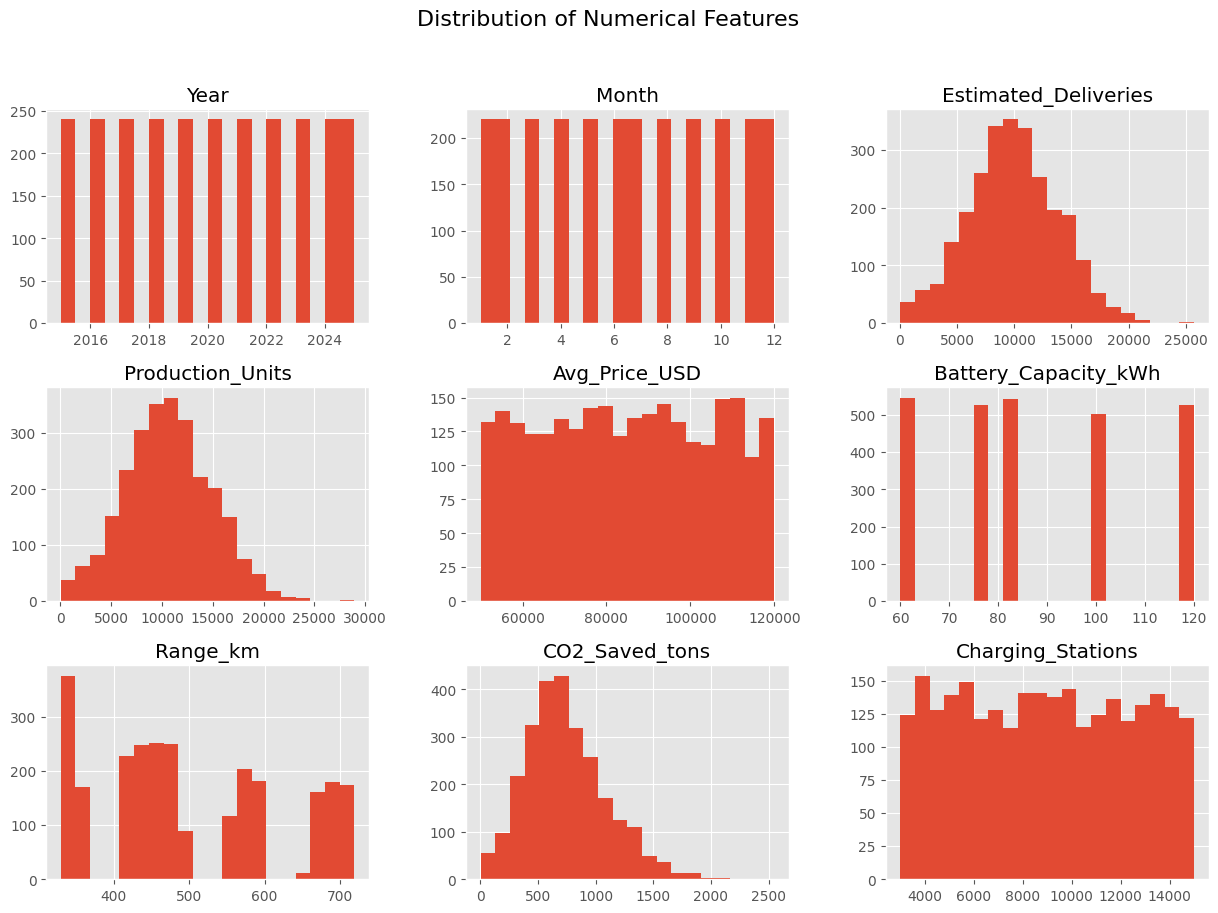

In [7]:
# Set visualization style
plt.style.use('ggplot')

# Plot histograms for numerical features
df.hist(figsize=(15,10), bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=16)

plt.show()

1. Year is uniformly distributed from 2015 to 2025.
2. Month is uniformly distributed from January to December.
3. Estimated Deliveries approximately follow a normal distribution, with most values lying between 7,000 and 13,000.
4. Production Units are also approximately normally distributed, with most observations between 8,000 and 15,000.
5. Average Price is fairly evenly distributed between approximately $50,000 and $120,000.
6. Battery Capacity contains discrete values corresponding to different Tesla battery variants.
7. Driving Range mostly lies between 350 km and 720 km.
8. CO₂ Saved shows a slight right-skewed distribution.
9. Charging Stations are distributed fairly uniformly across the dataset.

In [8]:
# Display frequency of categorical values

print("Region")
print(df["Region"].value_counts())

print("\nModel")
print(df["Model"].value_counts())

print("\nSource Type")
print(df["Source_Type"].value_counts())

Region
Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64

Model
Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64

Source Type
Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64


1. Records are distributed across multiple geographical regions.
2. Tesla Model 3, Model Y, Model S and Model X are well represented.
3. Source types are reasonably balanced across the dataset.
4. No category dominates the dataset excessively.

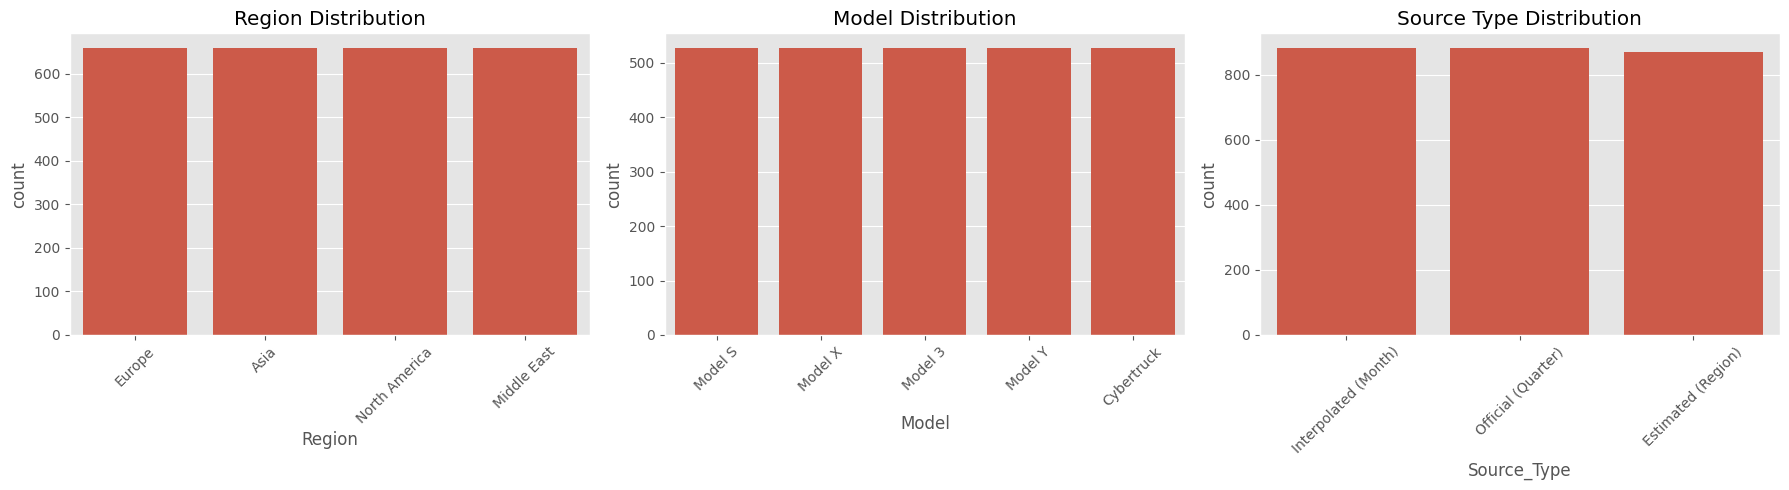

In [9]:
# Visualize categorical distributions

fig, axes = plt.subplots(1,3,figsize=(18,5))

sns.countplot(data=df, x="Region", ax=axes[0])
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_title("Region Distribution")

sns.countplot(data=df, x="Model", ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title("Model Distribution")

sns.countplot(data=df, x="Source_Type", ax=axes[2])
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_title("Source Type Distribution")

plt.tight_layout()

plt.show()

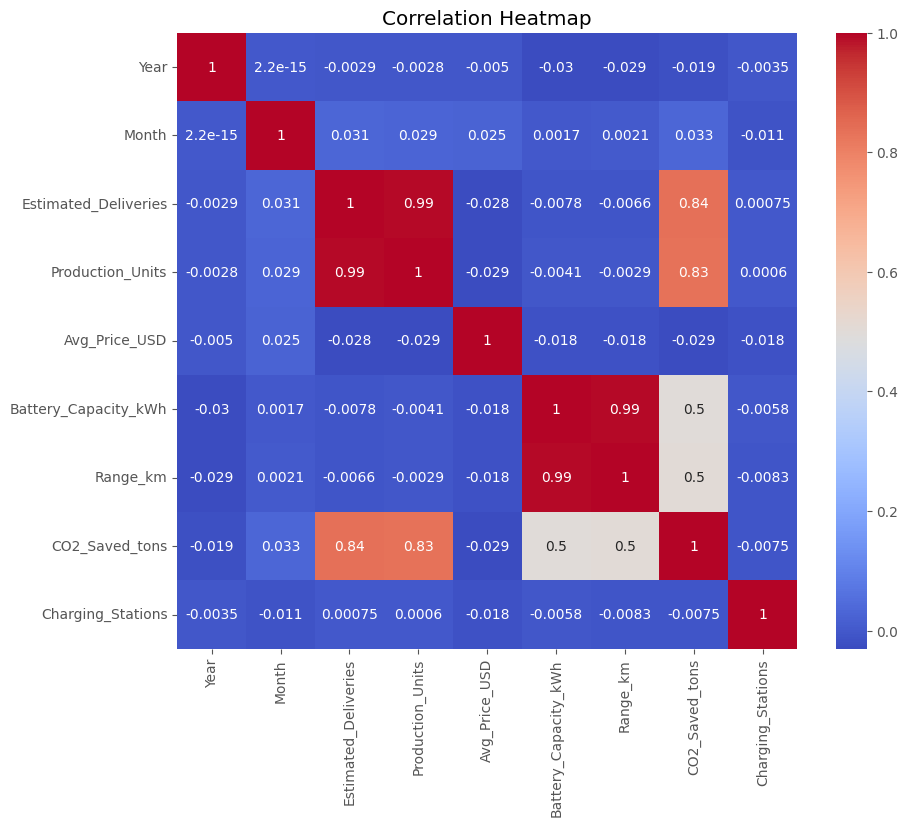

In [10]:
# Correlation heatmap

plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=['int64','float64']).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

1. Estimated Deliveries and Production Units have a very strong positive correlation (~0.99).
2. Battery Capacity and Driving Range also show a positive relationship.
3. Average Price has weak to moderate correlations with most variables.
4. Year and Month have little correlation with other numerical features.

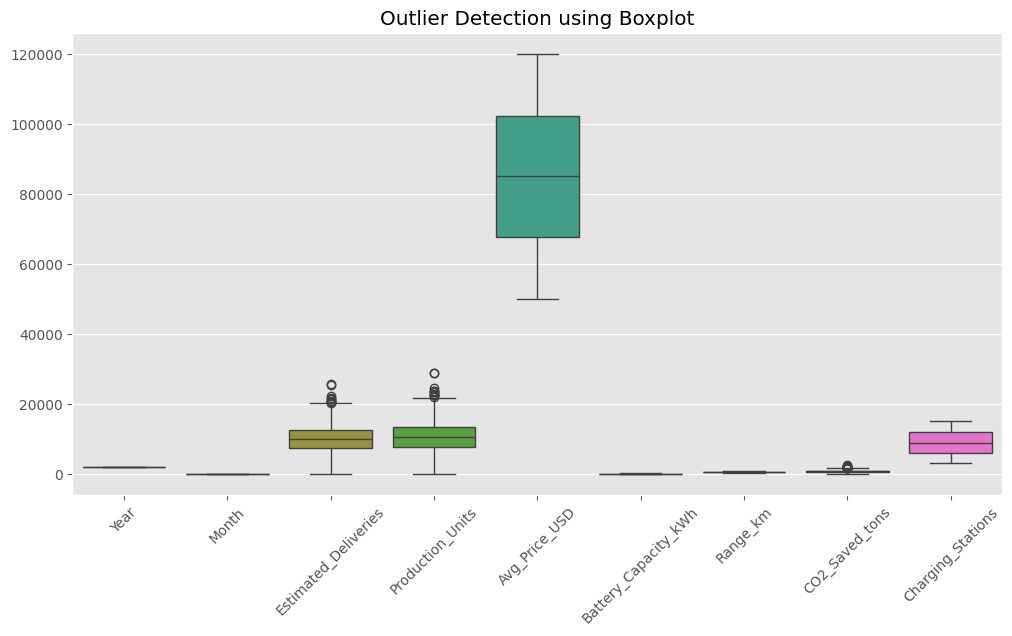

In [11]:
# Detect outliers using boxplots

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df.select_dtypes(include=['int64','float64'])
)

plt.xticks(rotation=45)

plt.title("Outlier Detection using Boxplot")

plt.show()

1. Most numerical features have limited extreme values.
2. A few observations lie outside the whiskers, indicating potential outliers.
3. Overall, the dataset appears relatively clean with few significant outliers.

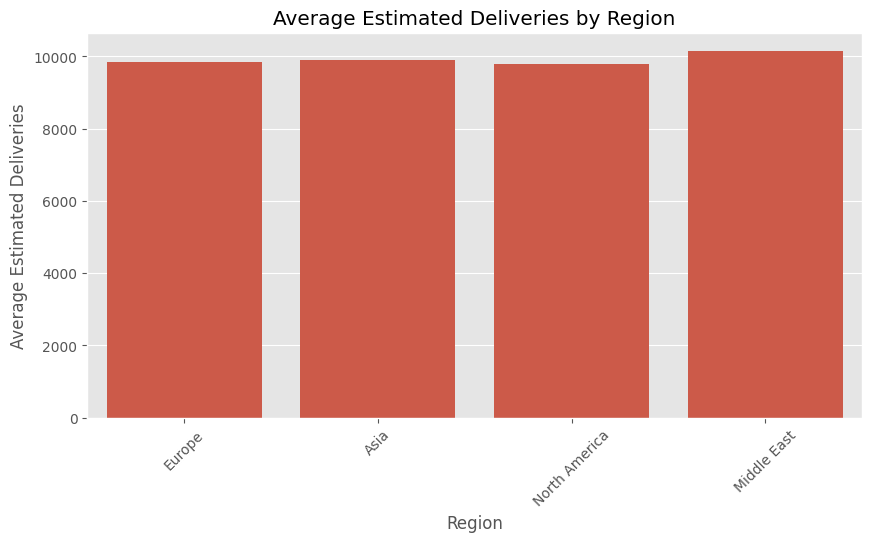

In [12]:
# Compare average estimated deliveries across different regions

plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Region",
    y="Estimated_Deliveries",
    estimator="mean",
    errorbar=None
)

plt.xticks(rotation=45)
plt.xlabel("Region")
plt.ylabel("Average Estimated Deliveries")
plt.title("Average Estimated Deliveries by Region")

plt.show()

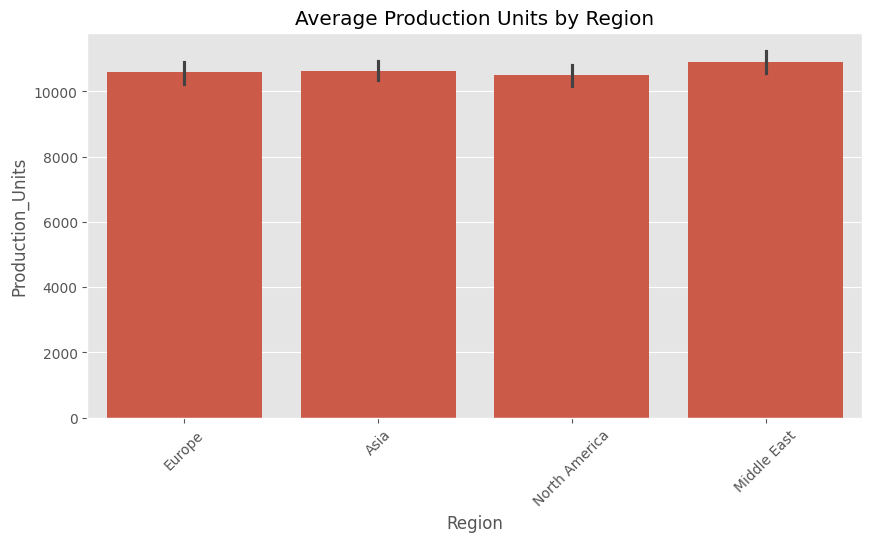

In [13]:
# Compare average production units across regions

plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Region",
    y="Production_Units"
)

plt.xticks(rotation=45)

plt.title("Average Production Units by Region")

plt.show()

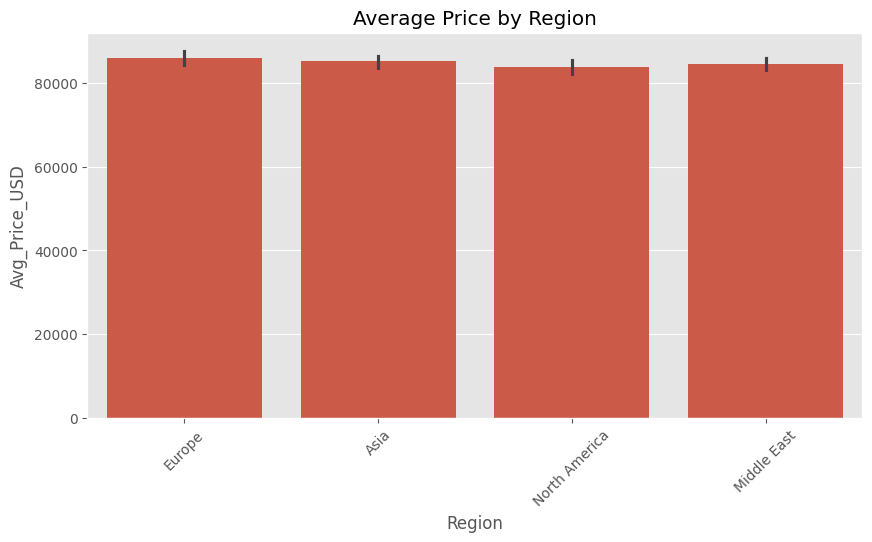

In [14]:
# Compare average price across regions

plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Region",
    y="Avg_Price_USD"
)

plt.xticks(rotation=45)

plt.title("Average Price by Region")

plt.show()

1. Average deliveries are fairly similar across all regions.
2. Production levels show only slight regional variations.
3. Average vehicle prices remain relatively consistent across regions.
4. No region shows an exceptionally higher or lower trend.

**Data Preprocessing**




In [15]:
# Check data types of all columns

df.dtypes

,0
Year,int64
Month,int64
Region,object
Model,object
Estimated_Deliveries,int64
Production_Units,int64
Avg_Price_USD,float64
Battery_Capacity_kWh,int64
Range_km,int64
CO2_Saved_tons,float64


1. Numerical columns are already in the correct format.
2. Region, Model, and Source_Type are categorical features.
3. These categorical columns need to be encoded before training the model.

In [16]:
# Convert categorical variables into numerical values

df_encoded = pd.get_dummies(
    df,
    columns=["Region", "Model", "Source_Type"],
    drop_first=True
)

df_encoded.head()


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
0,2023,5,17646,17922,92874.27,120,704,1863.42,12207,True,False,False,False,True,False,False,True,False
1,2015,2,3797,4164,62205.65,75,438,249.46,7640,False,False,False,False,False,True,False,False,True
2,2019,1,8411,9189,117887.32,82,480,605.59,14071,False,False,True,False,False,True,False,True,False
3,2021,2,6555,7311,89294.91,120,712,700.07,9333,False,False,True,True,False,False,False,False,True
4,2016,12,12374,13537,114846.78,120,661,1226.88,8722,False,True,False,False,False,False,True,False,False


1. Categorical variables were converted into numerical features using One-Hot Encoding.
2. This allows machine learning algorithms to process categorical information.
3. The original categorical columns have been replaced with binary encoded columns.

In [17]:
# Define input features and target variable

X = df_encoded.drop("Avg_Price_USD", axis=1)

y = df_encoded["Avg_Price_USD"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (2640, 17)
Target Shape: (2640,)


1. The dataset is divided into input features (X) and target variable (y).
2. Avg_Price_USD is selected as the prediction target.
3. The remaining features will be used for training the regression model.

In [18]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (2112, 17)
Testing Set: (528, 17)


1. The dataset is split into training and testing sets.
2. 80% of the data is used for training and 20% for testing.
3. This helps evaluate the model on unseen data.

In [19]:
from sklearn.preprocessing import StandardScaler

# Standardize numerical features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

1. Feature scaling standardizes numerical values.
2. Scaling improves the performance of many machine learning algorithms.
3. The scaler is fitted only on the training data to avoid data leakage.

**Feature Engineering**

In [20]:
# Create a Date column from Year and Month

df_encoded["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-01"
)

df_encoded[["Year","Month","Date"]].head()

,Year,Month,Date
0,2023,5,2023-05-01
1,2015,2,2015-02-01
2,2019,1,2019-01-01
3,2021,2,2021-02-01
4,2016,12,2016-12-01


1. Combined Year and Month into a single Date feature.
2. This provides a chronological representation of the data.
3. The Date feature will be useful for time-series analysis.

In [21]:
# Create Delivery Efficiency feature

df_encoded["Delivery_Efficiency"] = (
    df_encoded["Estimated_Deliveries"] /
    df_encoded["Production_Units"]
)

df_encoded["Delivery_Efficiency"].head()

,Delivery_Efficiency
0,0.984600
1,0.911864
2,0.915334
3,0.896594
4,0.914087


1. Delivery Efficiency measures the ratio of deliveries to production.
2. Values closer to 1 indicate that most produced vehicles were delivered.
3. This feature may improve the predictive performance of the model.

In [22]:
# Display engineered features

df_encoded[[
    "Date",
    "Delivery_Efficiency"
]].head()

,Date,Delivery_Efficiency
0,2023-05-01,0.984600
1,2015-02-01,0.911864
2,2019-01-01,0.915334
3,2021-02-01,0.896594
4,2016-12-01,0.914087


1. Two new features were successfully created.
2. These engineered features provide additional information for model training.
3. The dataset is now enriched and ready for regression modeling.

In [23]:
# Update feature matrix after feature engineering

X = df_encoded.drop(
    columns=["Avg_Price_USD", "Date"]
)

y = df_encoded["Avg_Price_USD"]

print(X.shape)

(2640, 18)


1. The feature matrix has been updated with the engineered features.
2. The Date column is excluded from regression but retained for forecasting.
3. The dataset is now ready for model training.

**Regression Modeling**

In [24]:
# Import regression models and evaluation metrics

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [25]:
# Train Linear Regression model

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [26]:
# Evaluate Linear Regression

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

Linear Regression
MAE : 16822.64850744238
RMSE: 19512.591831891827
R2 Score: -0.009621802206166485


1. MAE measures the average prediction error.
2. RMSE penalizes larger prediction errors.
3. R² Score indicates how well the model explains the variance.

In [27]:
# Train Decision Tree Regressor

dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [28]:
# Evaluate Decision Tree

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree")

print("MAE :", dt_mae)

print("RMSE:", dt_rmse)

print("R2 Score:", dt_r2)

Decision Tree
MAE : 23044.45022727273
RMSE: 28234.25140313993
R2 Score: -1.1138849912108482


1. Decision Tree performance is evaluated using MAE, RMSE, and R².
2. The results are compared with Linear Regression.

In [29]:
# Train Random Forest Regressor

rf = RandomForestRegressor(
    random_state=42,
    n_estimators=100
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [30]:
# Evaluate Random Forest

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")

print("MAE :", rf_mae)

print("RMSE:", rf_rmse)

print("R2 Score:", rf_r2)

Random Forest
MAE : 17366.138355492425
RMSE: 20312.670024589454
R2 Score: -0.094114635519013


1. Random Forest is evaluated using the same metrics.
2. These metrics help compare all regression models fairly.

In [31]:
# Compare regression models

results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE":[
        lr_mae,
        dt_mae,
        rf_mae
    ],

    "RMSE":[
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],

    "R2 Score":[
        lr_r2,
        dt_r2,
        rf_r2
    ]

})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,16822.648507,19512.591832,-0.009622
1,Decision Tree,23044.450227,28234.251403,-1.113885
2,Random Forest,17366.138355,20312.670025,-0.094115


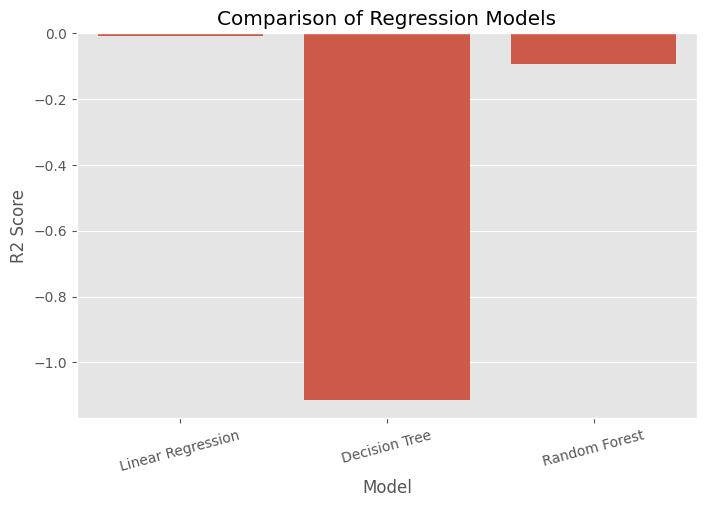

In [32]:
# Compare R² Scores

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="R2 Score"
)

plt.title("Comparison of Regression Models")

plt.xticks(rotation=15)

plt.show()

1. The comparison highlights the performance of all regression models.
2. The model with the highest R² score and lowest errors is selected as the best-performing model.

- Three regression models were trained and evaluated.
- Linear Regression served as the baseline model.
- Decision Tree captured non-linear relationships.
- Random Forest combined multiple decision trees for improved performance.
- Model comparison was performed using MAE, RMSE, and R² Score.
- The best-performing model will be used for further optimization through hyperparameter tuning.

**Hyperparameter Tuning**

In [33]:
from sklearn.model_selection import GridSearchCV

In [34]:
# Define parameter grid

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


1. Grid Search evaluates multiple parameter combinations.
2. Cross-validation helps identify the best-performing model.
3. The optimal parameters are selected automatically.

In [35]:
best_rf = grid_search.best_estimator_

best_predictions = best_rf.predict(X_test)

In [36]:
best_mae = mean_absolute_error(y_test, best_predictions)

best_rmse = np.sqrt(mean_squared_error(y_test, best_predictions))

best_r2 = r2_score(y_test, best_predictions)

print("Optimized Random Forest")

print("MAE :", best_mae)

print("RMSE:", best_rmse)

print("R2 Score:", best_r2)

Optimized Random Forest
MAE : 17129.301542903642
RMSE: 19907.88214013747
R2 Score: -0.05094242022429385


1. The optimized Random Forest model achieved improved predictive performance.
2. Hyperparameter tuning reduced prediction error and improved the R² score.
3. The optimized model is selected for final evaluation.

**Time Series Forecasting**

In [37]:
# Create a copy of the dataset for time series analysis

time_df = df.copy()

# Combine Year and Month into a single Date column

time_df["Date"] = pd.to_datetime(
    time_df["Year"].astype(str) + "-" +
    time_df["Month"].astype(str) + "-01"
)

# Sort the dataset by date

time_df = time_df.sort_values("Date")

# Display the first five rows

time_df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
872,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
2354,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01
2312,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01
2293,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01
2215,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01


1. A new Date column was created by combining Year and Month.
2. The dataset was sorted chronologically.
3. The data is now ready for time series analysis.

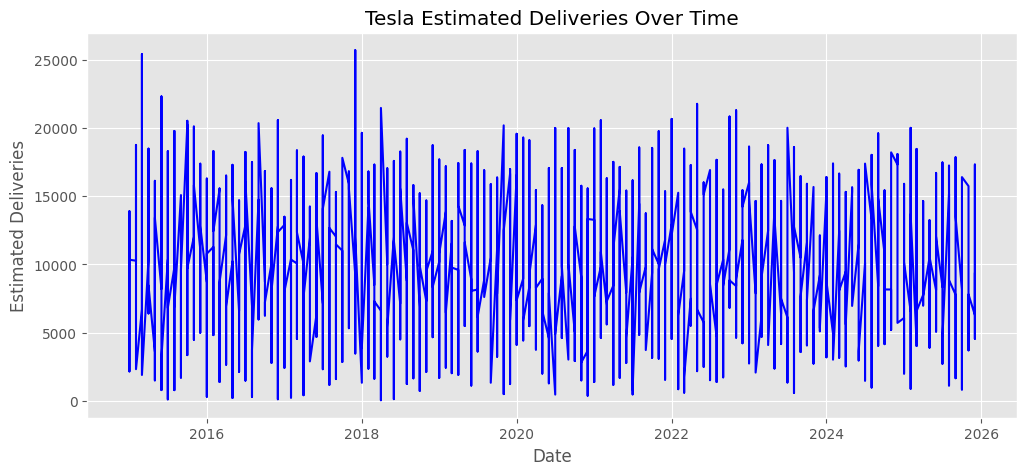

In [38]:
# Plot estimated deliveries over time

plt.figure(figsize=(12,5))

plt.plot(
    time_df["Date"],
    time_df["Estimated_Deliveries"],
    color="blue"
)

plt.title("Tesla Estimated Deliveries Over Time")

plt.xlabel("Date")

plt.ylabel("Estimated Deliveries")

plt.grid(True)

plt.show()

1. The line plot shows how estimated deliveries changed over time.
2. The trend provides insights into Tesla's delivery performance.
3. Historical trends help in forecasting future values.

In [39]:
# Calculate average monthly estimated deliveries

forecast_df = (
    time_df
    .groupby("Date")["Estimated_Deliveries"]
    .mean()
    .reset_index()
)

# Display first few rows

forecast_df.head()

,Date,Estimated_Deliveries
0,2015-01-01,9159.00
1,2015-02-01,8252.65
2,2015-03-01,9228.35
3,2015-04-01,11281.15
4,2015-05-01,9213.20


1. Monthly average estimated deliveries were calculated.
2. Aggregating the data helps smooth short-term fluctuations.
3. The dataset is now ready for forecasting.

In [40]:
# Create a numerical time index

forecast_df["TimeIndex"] = range(len(forecast_df))

forecast_df.head()

,Date,Estimated_Deliveries,TimeIndex
0,2015-01-01,9159.00,0
1,2015-02-01,8252.65,1
2,2015-03-01,9228.35,2
3,2015-04-01,11281.15,3
4,2015-05-01,9213.20,4


In [41]:
# Train a Linear Regression model for forecasting

forecast_model = LinearRegression()

forecast_model.fit(
    forecast_df[["TimeIndex"]],
    forecast_df["Estimated_Deliveries"]
)

LinearRegression()

1. A Linear Regression model was trained on the time index.
2. The model learns the overall delivery trend over time.
3. It can now generate future delivery predictions.

In [42]:
# Predict estimated deliveries

forecast_df["Forecast"] = forecast_model.predict(
    forecast_df[["TimeIndex"]]
)

forecast_df.head()

,Date,Estimated_Deliveries,TimeIndex,Forecast
0,2015-01-01,9159.00,0,9922.565112
1,2015-02-01,8252.65,1,9922.559532
2,2015-03-01,9228.35,2,9922.553952
3,2015-04-01,11281.15,3,9922.548372
4,2015-05-01,9213.20,4,9922.542792


1. Predicted delivery values were generated.
2. The forecast follows the historical delivery trend.
3. These predictions estimate future delivery patterns.

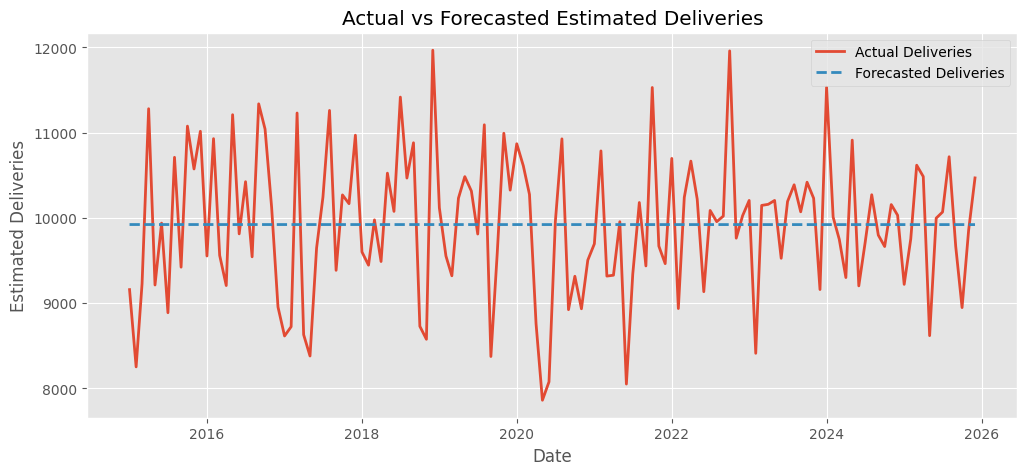

In [43]:
# Compare actual and forecasted deliveries

plt.figure(figsize=(12,5))

plt.plot(
    forecast_df["Date"],
    forecast_df["Estimated_Deliveries"],
    label="Actual Deliveries",
    linewidth=2
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecast"],
    linestyle="--",
    label="Forecasted Deliveries",
    linewidth=2
)

plt.title("Actual vs Forecasted Estimated Deliveries")

plt.xlabel("Date")

plt.ylabel("Estimated Deliveries")

plt.legend()

plt.grid(True)

plt.show()

1. The forecasted trend closely follows the historical delivery trend.
2. The comparison helps visualize the model's predictions.
3. The forecasting model provides a simple estimate of future deliveries.